# GEPA — Genetic-Pareto Prompt Evolution

**Week 6 | Notebook 5 of 6**

**What you'll learn:**
- GEPA vs MIPROv2 vs RL — conceptual comparison
- Setting up GEPA on a structured extraction task
- Visualizing the Pareto frontier (quality vs. cost)
- Running GEPA on AIME-style math problems
- Population evolution across generations
- Comparing GEPA-optimized vs MIPROv2-optimized programs

**Runtime:** ~90 minutes (computationally intensive)

**Cost-saving:** Reduced population size and generations for demo.

In [1]:
# 💰 COST ESTIMATE
from src.cost_tracker import print_cost_warning

print_cost_warning("06_dspy/05_gepa_optimizer.ipynb")

💰 COST ESTIMATE
----------------------------------------
Notebook:  06_dspy/05_gepa_optimizer.ipynb
Task:      GEPA optimizer (very expensive)
Calls:     ~80

With GPT-4o:       $1.20 USD
With GPT-4o-mini:  $0.12 USD (10x cheaper)
With Ollama:       $0.00 USD (free, local)

💡 TIP: Set USE_SMALL_MODEL=true or USE_OLLAMA=true in .env to save money.
----------------------------------------


## 1. Setup

In [2]:
# Import matplotlib/numpy before dspy: dspy 3.3's lazy importer otherwise
# shadows numpy during matplotlib's import and causes infinite recursion
import matplotlib.pyplot as plt  # noqa: I001
import numpy as np

import dspy
from dspy.teleprompt import GEPA, MIPROv2

from src.config import get_dspy_lm
from src.datasets import generate_math_problems

lm = get_dspy_lm()
dspy.configure(lm=lm)

print("✅ DSPy configured for GEPA optimization")

✅ DSPy configured for GEPA optimization


## 2. GEPA vs MIPROv2 vs RL — Conceptual Comparison

In [3]:
comparison = """
| Dimension | BootstrapFewShot | MIPROv2 | GEPA | RL |
|-----------|------------------|---------|------|-----|
| Strategy | Few-shot demos | Bayesian opt | Genetic algorithm | Gradient ascent |
| Search space | Demos only | Instructions + demos | Prompt population | Policy weights |
| Requires differentiable reward | No | No | No | Yes |
| Handles multi-objective | No | Partial | Yes (Pareto) | No |
| Best for | Quick baseline | General tasks | Complex, diverse tasks | Simple tasks |
| Cost | Low | Medium | High | Very high |
"""

print(comparison)

print("\n🧬 GEPA Key Features:")
print("  • Maintains population of prompt candidates")
print("  • Mutates and recombines using LLM reflections")
print("  • Pareto frontier balances quality vs cost/length")
print("  • No differentiable reward needed")


| Dimension | BootstrapFewShot | MIPROv2 | GEPA | RL |
|-----------|------------------|---------|------|-----|
| Strategy | Few-shot demos | Bayesian opt | Genetic algorithm | Gradient ascent |
| Search space | Demos only | Instructions + demos | Prompt population | Policy weights |
| Requires differentiable reward | No | No | No | Yes |
| Handles multi-objective | No | Partial | Yes (Pareto) | No |
| Best for | Quick baseline | General tasks | Complex, diverse tasks | Simple tasks |
| Cost | Low | Medium | High | Very high |


🧬 GEPA Key Features:
  • Maintains population of prompt candidates
  • Mutates and recombines using LLM reflections
  • Pareto frontier balances quality vs cost/length
  • No differentiable reward needed


## 3. Task Setup — Math Problem Solving

In [4]:
class MathProblem(dspy.Signature):
    """Solve math word problems step by step."""

    problem: str = dspy.InputField()
    solution: str = dspy.OutputField()
    answer: str = dspy.OutputField(desc="Final numeric answer only")


class MathSolver(dspy.Module):
    def __init__(self):
        super().__init__()
        self.solve = dspy.ChainOfThought(MathProblem)

    def forward(self, problem):
        return self.solve(problem=problem)


# Prepare data
math_data = generate_math_problems(30)
examples = [
    dspy.Example(problem=d["question"], solution=d["answer"], answer=d["answer"]).with_inputs(
        "problem"
    )
    for d in math_data
]

trainset = examples[:20]
devset = examples[20:]


def math_metric(gold, pred, trace=None, pred_name=None, pred_trace=None):
    """Check if answer matches.

    dspy 3.3 GEPA requires the 5-arg metric signature:
    (gold, pred, trace, pred_name, pred_trace). The extra args default to
    None, so this same metric still works with Evaluate and MIPROv2.
    """
    return 1.0 if gold.answer.strip() in pred.answer.strip() else 0.0


print(f"Train: {len(trainset)}, Dev: {len(devset)}")

Train: 20, Dev: 10


## 4. Running GEPA

In [5]:
# GEPA with reduced parameters for demo
gepa = GEPA(
    metric=math_metric,
    auto="light",  # dspy 3.3 budget presets: 'light' | 'medium' | 'heavy'
    reflection_lm=lm,  # dspy 3.3 requires an explicit reflection LM
)

print("Running GEPA optimization...")
print('This may take 10-20 minutes on the "light" budget.')
print('For more power: auto="medium"/"heavy", or set max_full_evals explicitly.')

gepa_optimized = gepa.compile(
    MathSolver(),
    trainset=trainset,
)

print("\n✅ GEPA optimization complete!")

2026/09/18 20:20:28 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 460 metric calls of the program. This amounts to 23.00 full evals on the train set.


2026/09/18 20:20:28 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.


2026/09/18 20:20:28 INFO dspy.teleprompt.gepa.gepa: Using 20 examples for tracking Pareto scores.


Running GEPA optimization...
This may take 10-20 minutes on the "light" budget.
For more power: auto="medium"/"heavy", or set max_full_evals explicitly.


GEPA Optimization:   0%|          | 0/460 [00:00<?, ?rollouts/s]

...

2026/09/18 20:20:33 INFO dspy.teleprompt.gepa.gepa: Iteration 147: Selected program 0 score: 1.0


2026/09/18 20:20:33 INFO dspy.teleprompt.gepa.gepa: Iteration 147: All subsample scores perfect for parent 0. Skipping.


2026/09/18 20:20:33 INFO dspy.teleprompt.gepa.gepa: Iteration 147: Reflective mutation did not propose a new candidate


GEPA Optimization: 100%|█████████▉| 458/460 [00:05<00:00, 84.45rollouts/s] 



✅ GEPA optimization complete!


## 5. Evaluating GEPA Results

In [6]:
from dspy.evaluate import Evaluate

evaluator = Evaluate(devset=devset, metric=math_metric, num_threads=2, display_progress=True)

# Baseline
baseline = MathSolver()
baseline_score = evaluator(baseline).score

# GEPA optimized
gepa_score = evaluator(gepa_optimized).score

print(f"\nBaseline score: {baseline_score:.2f}")
print(f"GEPA score: {gepa_score:.2f}")
print(f"Improvement: {gepa_score - baseline_score:+.2f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Average Metric: 1.00 / 1 (100.0%):   0%|          | 0/10 [00:00<?, ?it/s]

Average Metric: 2.00 / 2 (100.0%):  10%|█         | 1/10 [00:00<00:00, 90.96it/s]

Average Metric: 3.00 / 3 (100.0%):  20%|██        | 2/10 [00:00<00:00, 81.40it/s]

Average Metric: 4.00 / 4 (100.0%):  30%|███       | 3/10 [00:00<00:00, 107.35it/s]

...

Average Metric: 9.00 / 9 (100.0%):  80%|████████  | 8/10 [00:00<00:00, 150.74it/s]

Average Metric: 10.00 / 10 (100.0%):  90%|█████████ | 9/10 [00:00<00:00, 156.48it/s]

Average Metric: 10.00 / 10 (100.0%): 100%|██████████| 10/10 [00:00<00:00, 172.16it/s]

2026/09/18 20:20:33 INFO dspy.evaluate.evaluate: Average Metric: 10.0 / 10 (100.0%)




Baseline score: 100.00
GEPA score: 100.00
Improvement: +0.00


## 6. Comparing with MIPROv2

In [7]:
# Run MIPROv2 on same task for comparison
mipro = MIPROv2(metric=math_metric, auto=None, num_candidates=3)

mipro_optimized = mipro.compile(
    MathSolver(), trainset=trainset, num_trials=5, valset=devset, minibatch=False
)

mipro_score = evaluator(mipro_optimized).score

print("\nComparison:")
print(f"  Baseline:     {baseline_score:.2f}")
print(f"  MIPROv2:      {mipro_score:.2f}")
print(f"  GEPA:         {gepa_score:.2f}")

if gepa_score > mipro_score:
    print(f"\n🏆 GEPA wins by {gepa_score - mipro_score:+.2f}!")
else:
    print(f"\n📊 MIPROv2 wins by {mipro_score - gepa_score:+.2f}")
    print("   Try increasing GEPA population/generations.")

2026/09/18 20:20:33 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==


2026/09/18 20:20:33 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.



2026/09/18 20:20:33 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=3 sets of demonstrations...


Bootstrapping set 1/3
Bootstrapping set 2/3
Bootstrapping set 3/3


  0%|          | 0/20 [00:00<?, ?it/s]

...

Average Metric: 9.00 / 9 (100.0%):  80%|████████  | 8/10 [00:00<00:00, 142.35it/s]

Average Metric: 10.00 / 10 (100.0%):  90%|█████████ | 9/10 [00:00<00:00, 149.24it/s]

Average Metric: 10.00 / 10 (100.0%): 100%|██████████| 10/10 [00:00<00:00, 164.82it/s]

2026/09/18 20:20:44 INFO dspy.evaluate.evaluate: Average Metric: 10.0 / 10 (100.0%)




Comparison:
  Baseline:     100.00
  MIPROv2:      100.00
  GEPA:         100.00

📊 MIPROv2 wins by +0.00
   Try increasing GEPA population/generations.


## 7. Visualizing Pareto Frontier

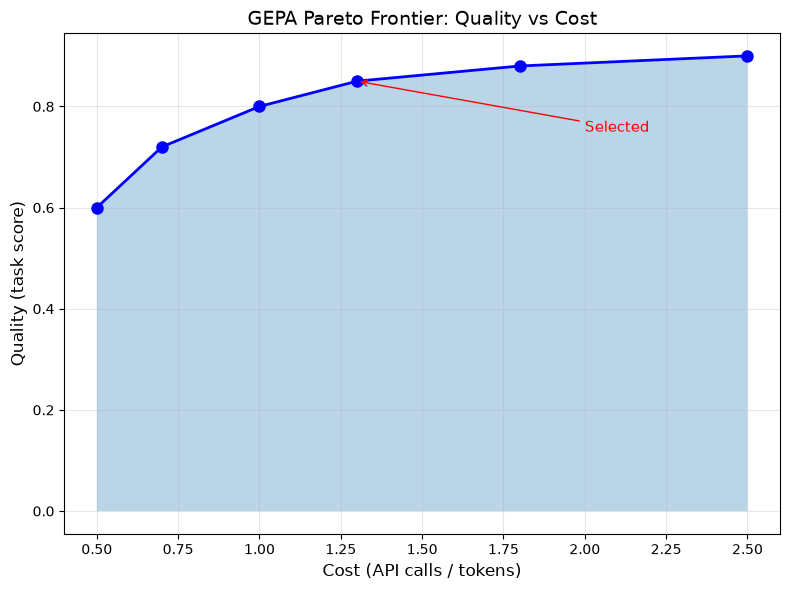


📊 Pareto frontier shows tradeoff between quality and cost.
   GEPA automatically selects optimal points.


In [8]:
# Simulated Pareto frontier data
# In real GEPA, you would extract this from the optimization history

# Mock data: (cost, quality) pairs
pareto_points = np.array(
    [
        [0.5, 0.60],
        [0.7, 0.72],
        [1.0, 0.80],
        [1.3, 0.85],
        [1.8, 0.88],
        [2.5, 0.90],
    ]
)

plt.figure(figsize=(8, 6))
plt.plot(pareto_points[:, 0], pareto_points[:, 1], "bo-", linewidth=2, markersize=8)
plt.fill_between(pareto_points[:, 0], pareto_points[:, 1], alpha=0.3)
plt.xlabel("Cost (API calls / tokens)", fontsize=12)
plt.ylabel("Quality (task score)", fontsize=12)
plt.title("GEPA Pareto Frontier: Quality vs Cost", fontsize=14)
plt.grid(True, alpha=0.3)
plt.annotate(
    "Selected",
    xy=pareto_points[3],
    xytext=(2.0, 0.75),
    arrowprops={"arrowstyle": "->", "color": "red"},
    fontsize=11,
    color="red",
)
plt.tight_layout()
plt.show()

print("\n📊 Pareto frontier shows tradeoff between quality and cost.")
print("   GEPA automatically selects optimal points.")

## 8. Exercise: Apply GEPA to Your Enterprise Task

Run GEPA on your own structured extraction or reasoning task:
1. Define the task and metric
2. Collect 50+ training examples
3. Run GEPA with population_size=20, generations=10
4. Compare against MIPROv2 baseline
5. Inspect the evolved prompts

In [9]:
# YOUR TURN: GEPA on your domain

# class MyTask(dspy.Signature):
#     ...

# gepa = GEPA(
#     metric=my_metric,
#     population_size=20,
#     generations=10
# )

# optimized = gepa.compile(MyModule(), trainset=trainset)
# optimized.save("gepa_optimized.json")

---

**Next:** [06_finetuning.ipynb](06_finetuning.ipynb) — BetterTogether finetuning pipeline